# 🎓 Smart Education AI: Student Performance Segmentation
**Advanced Unsupervised Learning Pipeline using Ensemble Clustering (K-Means + Fuzzy C-Means)**

---
### 📌 Project Overview
This notebook presents a state-of-the-art approach to identifying at-risk students and high-performers using advanced **unsupervised machine learning**. 

Instead of relying solely on hard boundaries, this pipeline implements **Fuzzy C-Means (FCM)** and **Rough-Fuzzy Classification** to capture the overlapping, nuanced nature of student behavior. 

### 🚀 Key Innovations:
1. **Advanced Feature Engineering:** Moving beyond raw grades to quantify `Consistency`, `Effort`, and `Social Risk`.
2. **Rough-Fuzzy Boundary Detection:** Identifying "borderline" students whose performance is unstable.
3. **Smart Recommendation Engine:** Dynamically generating personalized, actionable interventions for at-risk students based on their unique data profiles.


In [1]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 13.4 MB/s eta 0:00:00


In [2]:
# =============================================================================
# PHASE 1: SYSTEM SETUP & IMPORTS
# =============================================================================

import os
import warnings
warnings.filterwarnings('ignore')

# Optimize multi-threading for Windows / Jupyter to prevent memory leaks
os.environ['LOKY_MAX_CPU_COUNT'] = '4'  
os.environ['OMP_NUM_THREADS'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from math import pi

# Scikit-Learn tools
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Fuzzy Logic
import skfuzzy as fuzz

# Set aesthetic styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")


---
## 📊 Phase 2: Data Loading & Preprocessing


In [3]:
# Load Dataset
import os

if os.path.exists("/kaggle/input"):
    df = pd.read_csv("/kaggle/input/datasets/sourav171/student-dataset/student_data.csv")
else:
    df = pd.read_csv("data/student_data.csv")

print(f"Dataset Shape: {df.shape}")
print("-" * 40)

# Binary Encoding mapping
binary_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'yes': 1, 'no': 0})

# Display a quick snapshot


Dataset Shape: (395, 33)
----------------------------------------


---
## 🧠 Phase 3: Advanced Feature Engineering
We construct robust, domain-specific features that better represent a student's holistic academic profile than raw math scores alone.

1. **Performance:** The average of G1, G2, and G3.
2. **Consistency:** The standard deviation/variance across the three grading periods. High variance indicates unstable performance.
3. **Effort Index:** Ratio of study time to failures.
4. **Social Risk:** Combination of going out and alcohol consumption.


In [4]:
# 1. Academic Performance
df['Performance'] = df[['G1', 'G2', 'G3']].mean(axis=1)

# 2. Academic Consistency (Variance of grades)
# Lower variance = More consistent. We'll use standard deviation.
df['Consistency'] = df[['G1', 'G2', 'G3']].std(axis=1).fillna(0)

# 3. Effort Index (studytime relative to past failures)
df['Effort'] = df['studytime'] / (1 + df['failures'])

# 4. Social Risk Factor
df['Social_Risk'] = df['goout'] + df['Dalc'] + df['Walc']

# 5. Support Index (School + Family + Extra Classes)
df['Support_Index'] = df['schoolsup'] + df['famsup'] + df['paid']

# Select final features for clustering
clustering_features = ['Performance', 'Consistency', 'absences', 'Effort', 'Social_Risk']

X = df[clustering_features].copy()

# Feature Scaling (Crucial for distance-based clustering algorithms)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Feature Engineering and Scaling Complete.")


✅ Feature Engineering and Scaling Complete.


---
## 📐 Phase 4: Determining Optimal Clusters (Elbow & Silhouette)


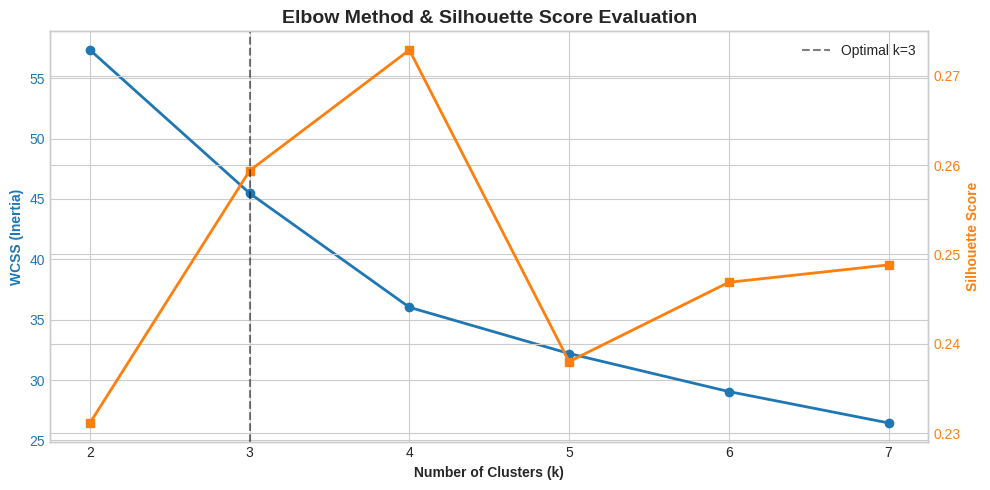

In [5]:
wcss = []
silhouette_scores = []
K_RANGE = range(2, 8)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot WCSS (Elbow)
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)', fontweight='bold')
ax1.set_ylabel('WCSS (Inertia)', color=color, fontweight='bold')
ax1.plot(K_RANGE, wcss, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

# Plot Silhouette
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Silhouette Score', color=color, fontweight='bold')  
ax2.plot(K_RANGE, silhouette_scores, marker='s', color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Elbow Method & Silhouette Score Evaluation", fontsize=14, fontweight='bold')
plt.axvline(x=3, color='black', linestyle='--', alpha=0.5, label='Optimal k=3')
plt.legend()
plt.tight_layout()
plt.show()



---
## 🤖 Phase 5: Hard & Soft Clustering (K-Means + Fuzzy C-Means)


In [6]:
N_CLUSTERS = 3

# 1. K-Means (Hard Clustering)
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# 2. Fuzzy C-Means (Soft Clustering)
# Note: skfuzzy requires shape (n_features, n_samples)
X_fcm = X_scaled.T

# cntr: centers, u: membership matrix (probability belonging to each cluster)
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_fcm, c=N_CLUSTERS, m=2, error=0.005, maxiter=1000, init=None, seed=42
)

# Extract primary fuzzy cluster and confidence
df['FCM_Cluster'] = np.argmax(u, axis=0)
df['FCM_Confidence'] = np.max(u, axis=0)

# Save the membership matrix for later visualization
fuzzy_memberships = u.T 

# 3. Label Alignment (Handling Cluster Permutation)
# Ensure FCM cluster IDs semantically match KMeans cluster IDs by ordering them by Performance
cluster_means_fcm = df.groupby('FCM_Cluster')['Performance'].mean().sort_values()

# Map: 0 -> At-Risk, 1 -> Average, 2 -> High Performer
mapping = {
    cluster_means_fcm.index[0]: 0, # Lowest performance
    cluster_means_fcm.index[1]: 1, # Middle
    cluster_means_fcm.index[2]: 2  # Highest performance
}

df['Final_Cluster'] = df['FCM_Cluster'].map(mapping)
# Reorder fuzzy memberships to match the new semantic meaning
ordered_u = np.zeros_like(u)
ordered_u[0, :] = u[cluster_means_fcm.index[0], :]
ordered_u[1, :] = u[cluster_means_fcm.index[1], :]
ordered_u[2, :] = u[cluster_means_fcm.index[2], :]
fuzzy_memberships = ordered_u.T

df['FCM_Confidence'] = np.max(ordered_u, axis=0)

semantic_labels = {
    0: '🔴 At-Risk',
    1: '🟡 Average / Borderline',
    2: '🟢 High Performer'
}
df['Category'] = df['Final_Cluster'].map(semantic_labels)



---
## ⚠️ Phase 6: Rough-Fuzzy Borderline Detection
In traditional clustering, a student is strictly "Average" or "At-Risk". Using our fuzzy probabilities, we define a **Rough-Fuzzy Threshold**. 



In [7]:
# Sort probabilities for each student to find top 2
sorted_u = np.sort(fuzzy_memberships, axis=1)
top_1_prob = sorted_u[:, -1]
top_2_prob = sorted_u[:, -2]
prob_diff = top_1_prob - top_2_prob

DELTA_THRESHOLD = 0.15
CONFIDENCE_THRESHOLD = 0.60

# Condition: Either primary confidence is low, or the gap between top 2 is small
df['Is_Borderline'] = (df['FCM_Confidence'] < CONFIDENCE_THRESHOLD) | (prob_diff < DELTA_THRESHOLD)

borderline_count = df['Is_Borderline'].sum()
print(f"🚨 Identified {borderline_count} Borderline Students ({round(borderline_count/len(df)*100, 1)}% of total).")


🚨 Identified 273 Borderline Students (69.1% of total).


---
## 🏆 Phase 7: Model Evaluation Criteria


In [8]:
sil_score = silhouette_score(X_scaled, df['Final_Cluster'])
db_score = davies_bouldin_score(X_scaled, df['Final_Cluster'])
ch_score = calinski_harabasz_score(X_scaled, df['Final_Cluster'])

print("--- CLUSTERING METRICS ---")
print(f"Silhouette Score:      {sil_score:.4f} (Higher is better, >0 indicates separation)")
print(f"Davies-Bouldin Index:  {db_score:.4f} (Lower is better, dense clusters)")


--- CLUSTERING METRICS ---
Silhouette Score:      0.1808 (Higher is better, >0 indicates separation)
Davies-Bouldin Index:  1.7147 (Lower is better, dense clusters)


---
## 📈 Phase 8: Cluster Profiling & Publication-Quality Dashboard


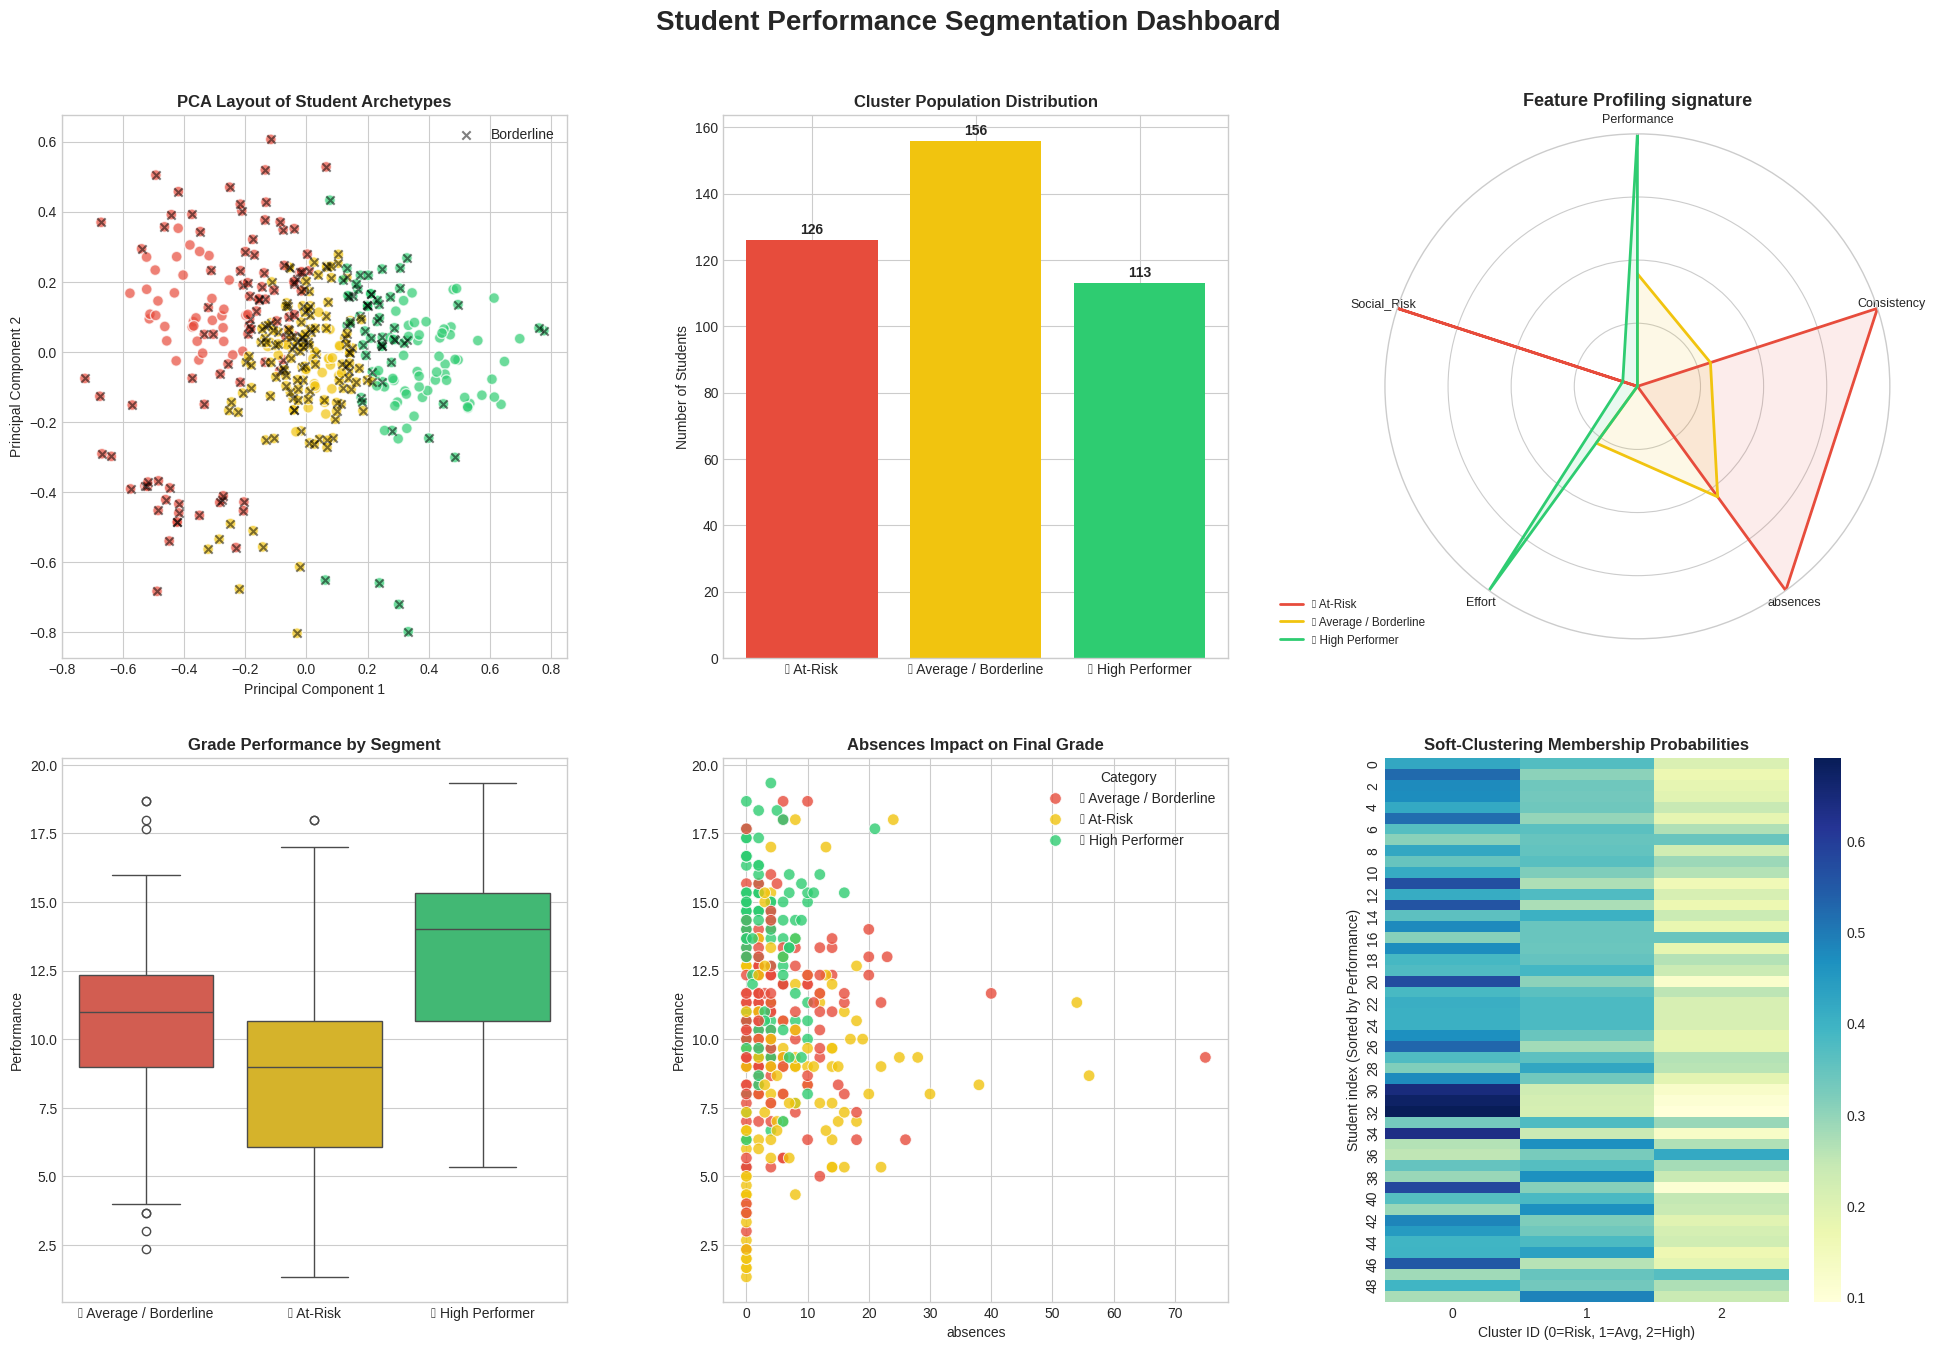

In [9]:
# Calculate Cluster Profiles for Radar Chart
cluster_profiles = df.groupby('Final_Cluster')[clustering_features].mean()

# Normalizing the profiles for the radar chart (Min-Max per feature)
profile_scaler = MinMaxScaler()
radar_data = profile_scaler.fit_transform(cluster_profiles)

def make_radar_chart(ax, data, attributes, title):
    N = len(attributes)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(attributes, size=9)
    ax.set_rlabel_position(0)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(["", "", ""], color="grey", size=7)
    ax.set_ylim(0, 1)
    
    colors = ['#e74c3c', '#f1c40f', '#2ecc71'] # Red, Yellow, Green
    
    for i in range(len(data)):
        values = data[i].tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=semantic_labels[i], color=colors[i])
        ax.fill(angles, values, color=colors[i], alpha=0.1)
        
    ax.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1), fontsize='small')
    ax.set_title(title, size=13, fontweight='bold', pad=20)

# Create Master Figure
fig = plt.figure(figsize=(20, 14))
fig.suptitle("Student Performance Segmentation Dashboard", fontsize=20, fontweight='bold', y=0.98)

colors = ['#e74c3c', '#f1c40f', '#2ecc71']

# 1. PCA Scatter Plot
ax1 = plt.subplot(231)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
scatter = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Final_Cluster'], cmap=plt.cm.colors.ListedColormap(colors), alpha=0.7, edgecolors='w', s=60)
# Mark borderline students with 'X'
borderlines = X_pca[df['Is_Borderline']]
ax1.scatter(borderlines[:, 0], borderlines[:, 1], marker='x', color='black', alpha=0.5, label='Borderline')
ax1.set_title('PCA Layout of Student Archetypes', fontweight='bold')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.legend()

# 2. Cluster Distribution
ax2 = plt.subplot(232)
dist = df['Category'].value_counts().sort_index()
bars = ax2.bar(dist.index, dist.values, color=colors)
ax2.set_title('Cluster Population Distribution', fontweight='bold')
ax2.set_ylabel('Number of Students')
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontweight='bold')

# 3. Radar Chart Profiling
ax3 = plt.subplot(233, polar=True)
make_radar_chart(ax3, radar_data, clustering_features, 'Feature Profiling signature')

# 4. Boxplot of Performance
ax4 = plt.subplot(234)
sns.boxplot(x='Category', y='Performance', data=df, palette=colors, ax=ax4)
ax4.set_title('Grade Performance by Segment', fontweight='bold')
ax4.set_xlabel('')

# 5. Absences vs Performance Scatter
ax5 = plt.subplot(235)
sns.scatterplot(x='absences', y='Performance', hue='Category', palette=colors, data=df, ax=ax5, s=70, alpha=0.8)
ax5.set_title('Absences Impact on Final Grade', fontweight='bold')

# 6. Fuzzy Membership Heatmap (Top 50 students sorted by Performance)
ax6 = plt.subplot(236)
sample_idx = df.sort_values('Performance').head(50).index
sns.heatmap(fuzzy_memberships[sample_idx], cmap='YlGnBu', cbar=True, ax=ax6)
ax6.set_title('Soft-Clustering Membership Probabilities', fontweight='bold')
ax6.set_xlabel('Cluster ID (0=Risk, 1=Avg, 2=High)')
ax6.set_ylabel('Student index (Sorted by Performance)')

plt.tight_layout(pad=3.0)
plt.savefig('Segmentation_Dashboard.png', dpi=300, bbox_inches='tight')


---
## 💡 Phase 9: AI Smart Recommendation Engine


In [10]:
print("=" * 80)
print(" 🎓 SMART AI: PERSONALIZED TARGETED INTERVENTION ENGINE 🎓")
print("=" * 80)

# Filter students requiring attention
target_students = df[(df['Final_Cluster'] == 0) | (df['Is_Borderline'] == True)].copy()

# Sort by lowest performance for triage prioritization
target_students = target_students.sort_values(by='Performance').head(10)

print(f"Generating personalized action plans for top priority cases...\n")

for idx, row in target_students.iterrows():
    status = row['Category']
    if row['Is_Borderline']:
        status += " (🚨 BORDERLINE RISK OVERLAP)"
        
    print(f"▶ STUDENT ID: {idx} | Status: {status}")
    print(f"  Confidence Score: {row['FCM_Confidence']*100:.1f}%")
    print(f"  Key Stats: Avg Grade={row['Performance']:.1f}, Absences={row['absences']}, Consistency(Var)={row['Consistency']:.1f}")
    
    recs = []
    
    # Logic 1: High Absences
    if row['absences'] >= 8:
        recs.append("Trigger automated attendance alert to parents. Schedule counselor meeting.")
        
    # Logic 2: High Inconsistency (High Variance)
    if row['Consistency'] >= 3.0:
        recs.append("Highly unstable grading detected. Implement weekly continuous assessment checkpoints.")
        
    # Logic 3: High Social Risk
    if row['Social_Risk'] >= 6:
        recs.append("Behavioral flag: High social/weekend activity. Assign peer mentor for structured routine.")
        
    # Logic 4: Low Effort despite low grades
    if row['Effort'] <= 0.5:
        recs.append("Low study-time ratio. Enroll in mandatory after-school study halls.")
        
    # Generic fallback
    if len(recs) == 0:
        recs.append("Schedule general 1-on-1 check-in to assess engagement and well-being.")
        
    print("  Recommended Actions:")
    for i, rec in enumerate(recs, 1):
        print(f"   {i}. {rec}")


 🎓 SMART AI: PERSONALIZED TARGETED INTERVENTION ENGINE 🎓
Generating personalized action plans for top priority cases...

▶ STUDENT ID: 137 | Status: 🔴 At-Risk (🚨 BORDERLINE RISK OVERLAP)
  Confidence Score: 42.3%
  Key Stats: Avg Grade=1.3, Absences=0, Consistency(Var)=2.3
  Recommended Actions:
   1. Low study-time ratio. Enroll in mandatory after-school study halls.
▶ STUDENT ID: 153 | Status: 🔴 At-Risk (🚨 BORDERLINE RISK OVERLAP)
  Confidence Score: 47.6%
  Key Stats: Avg Grade=1.7, Absences=0, Consistency(Var)=2.9
  Recommended Actions:
   1. Behavioral flag: High social/weekend activity. Assign peer mentor for structured routine.
   2. Low study-time ratio. Enroll in mandatory after-school study halls.
▶ STUDENT ID: 144 | Status: 🔴 At-Risk (🚨 BORDERLINE RISK OVERLAP)
  Confidence Score: 52.4%
  Key Stats: Avg Grade=1.7, Absences=0, Consistency(Var)=2.9
  Recommended Actions:
   1. Behavioral flag: High social/weekend activity. Assign peer mentor for structured routine.
   2. Low s

---
## 💾 Phase 10: Export Pipeline


In [11]:
# Export complete mapped dataset
df.to_csv('Student_Segmentation_Final_Output.csv', index=False)

# Export Cluster Summary Stats
summary = df.groupby('Category')[clustering_features].mean().round(2)
summary.to_csv('Cluster_Profiling_Summary.csv')

